# Import Libraries


In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt

# Load Text Corpus


In [2]:
corpus = """
deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences
machine learning enables intelligent decision making
natural language processing helps computers understand text
artificial intelligence is changing the world
neural networks learn patterns from data
"""

# Tokenization


In [3]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1

print("Vocabulary Size:", total_words)

Vocabulary Size: 52


# Input Sequences


In [4]:
input_sequences = []

for line in corpus.split("\n"):
    
    token_list = tokenizer.texts_to_sequences([line])[0]

    for i in range(1, len(token_list)):
        n_gram_sequence = token_list[:i + 1]
        input_sequences.append(n_gram_sequence)

print("Total Sequences:", len(input_sequences))

Total Sequences: 56


# Padding Sequences


In [5]:
max_sequence_len = max([len(x) for x in input_sequences])

input_sequences = pad_sequences(
    input_sequences,
    maxlen=max_sequence_len,
    padding='pre'
)

print("Maximum Sequence Length:", max_sequence_len)

Maximum Sequence Length: 8


# Features and Labels


In [6]:
X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (56, 7)
y Shape: (56,)


# PART A: VANILLA RNN


Build RNN Model


In [10]:
from tensorflow.keras.layers import Input

rnn_model = Sequential([
    Input(shape=(max_sequence_len - 1,)),
    Embedding(total_words, 64),
    SimpleRNN(128),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

rnn_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 7, 64)          │         3,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ (None, 128)            │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 52)             │         6,708 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,740 (135.70 KB)

 Trainable params: 34,740 (135.70 KB)

 Non-trainable params: 0 (0.00 B)

Train RNN Model


In [11]:
rnn_history = rnn_model.fit(
    X,
    y,
    epochs=200,
    verbose=1
)

Epoch 1/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.0119 - loss: 3.9612     
Epoch 2/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.0565 - loss: 3.8859 
Epoch 3/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.1027 - loss: 3.8296 
Epoch 4/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.0685 - loss: 3.7544
Epoch 5/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.0580 - loss: 3.6964 
Epoch 6/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.0580 - loss: 3.6710
Epoch 7/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.0685 - loss: 3.5938
Epoch 8/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.0580 - loss: 3.5352
Epoch 9/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.2143 - loss: 3.4607
Epoch 10/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.2470 - loss: 3.3892 
Epoch 11/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.2976 - loss: 3.3439
Epoch 12/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3631 -

Evaluate RNN


In [12]:
rnn_loss, rnn_acc = rnn_model.evaluate(
    X,
    y,
    verbose=0
)

print("RNN Accuracy:", rnn_acc)

RNN Accuracy: 0.9821428656578064


# PART B: LSTM


Build LSTM Model


In [13]:
lstm_model = Sequential([
    Input(shape=(max_sequence_len - 1,)),
    Embedding(total_words, 64),
    LSTM(128),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

lstm_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 7, 64)          │         3,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 52)             │         6,708 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 108,852 (425.20 KB)

 Trainable params: 108,852 (425.20 KB)

 Non-trainable params: 0 (0.00 B)

Train LSTM Model


In [14]:
lstm_history = lstm_model.fit(
    X,
    y,
    epochs=200,
    verbose=1
)

Epoch 1/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.0000e+00 - loss: 3.9511 
Epoch 2/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.0461 - loss: 3.9438
Epoch 3/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.0357 - loss: 3.9365    
Epoch 4/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.0565 - loss: 3.9274
Epoch 5/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.0893 - loss: 3.9174
Epoch 6/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.0685 - loss: 3.9075
Epoch 7/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.0685 - loss: 3.8931
Epoch 8/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.0789 - loss: 3.8706
Epoch 9/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.0685 - loss: 3.8449
Epoch 10/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.0580 - loss: 3.8116
Epoch 11/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.0580 - loss: 3.7522
Epoch 12/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.

Evaluate LSTM


In [15]:
lstm_loss, lstm_acc = lstm_model.evaluate(
    X,
    y,
    verbose=0
)

print("LSTM Accuracy:", lstm_acc)

LSTM Accuracy: 0.9821428656578064


# PART C: GRU


Build GRU Model


In [16]:
gru_model = Sequential([
    Input(shape=(max_sequence_len - 1,)),
    Embedding(total_words, 64),
    GRU(128),
    Dense(total_words, activation='softmax')
])

gru_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

gru_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 7, 64)          │         3,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 128)            │        74,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 52)             │         6,708 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 84,532 (330.20 KB)

 Trainable params: 84,532 (330.20 KB)

 Non-trainable params: 0 (0.00 B)

Train GRU Model


In [17]:
gru_history = gru_model.fit(
    X,
    y,
    epochs=200,
    verbose=1
)

Epoch 1/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.0000e+00 - loss: 3.9510 
Epoch 2/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.0357 - loss: 3.9381    
Epoch 3/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.0908 - loss: 3.9241
Epoch 4/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.0789 - loss: 3.9113
Epoch 5/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.0461 - loss: 3.9012
Epoch 6/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.0670 - loss: 3.8810
Epoch 7/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.0461 - loss: 3.8648
Epoch 8/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.0461 - loss: 3.8414
Epoch 9/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.0565 - loss: 3.8160
Epoch 10/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.0565 - loss: 3.7770
Epoch 11/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.0565 - loss: 3.7412
Epoch 12/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.

Evaluate GRU


In [18]:
gru_loss, gru_acc = gru_model.evaluate(
    X,
    y,
    verbose=0
)

print("GRU Accuracy:", gru_acc)

GRU Accuracy: 0.9821428656578064


# PART D: Compare Training Loss


Loss Curves


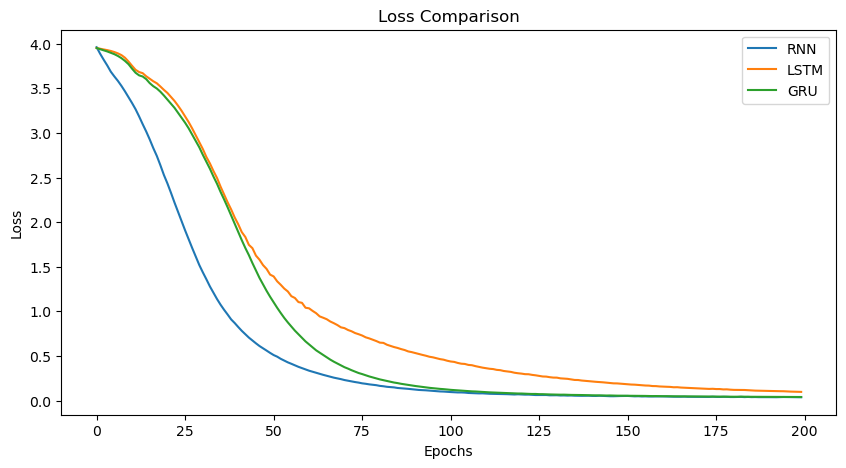

In [19]:
plt.figure(figsize=(10,5))

plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Comparison")

plt.legend()
plt.show()

# PART E: Text Generation Function


Define Text Generator


In [20]:
def generate_text(model, seed_text, next_words):

    for _ in range(next_words):

        token_list = tokenizer.texts_to_sequences(
            [seed_text]
        )[0]

        token_list = pad_sequences(
            [token_list],
            maxlen=max_sequence_len - 1,
            padding='pre'
        )

        predicted = np.argmax(
            model.predict(token_list, verbose=0),
            axis=-1
        )[0]

        output_word = ""

        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break

        seed_text += " " + output_word

    return seed_text

Generate Text using RNN


In [21]:
print(generate_text(
    rnn_model,
    "deep learning",
    8
))

deep learning models can generate meaningful sentences faster and simpler


Generate Text using LSTM


In [22]:
print(generate_text(
    lstm_model,
    "deep learning",
    8
))

deep learning is transforming artificial intelligence intelligence intelligence world lstm


Generate Text using GRU


In [23]:
print(generate_text(
    gru_model,
    "deep learning",
    8
))

deep learning models can generate meaningful sentences sentences data sentences


# Final Comparison Table


In [24]:
print("\nModel Performance")

print("RNN Accuracy :", round(rnn_acc,4))
print("LSTM Accuracy:", round(lstm_acc,4))
print("GRU Accuracy :", round(gru_acc,4))


Model Performance
RNN Accuracy : 0.9821
LSTM Accuracy: 0.9821
GRU Accuracy : 0.9821
